# Imports

In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import celldega as dega
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np

from shapely.geometry import Polygon
from shapely import points

print(dega.__version__)

env: ANYWIDGET_HMR=1


/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_red

0.14.2


# User Inputs

In [2]:
sample = 'Xenium_Prime_Human_Skin_FFPE_outs'
data_dir = f'data/xenium_data/'
path_landscape_files=f'data/landscape_files/{sample}_06_OCT_2025'

# Annotate ROIs in Celldega

In [3]:
# landscape = dega.viz.Landscape(
#     technology='Xenium',
#     base_url = f"http://localhost:{dega.viz.get_local_server()}/{path_landscape_files}",
#     nbhd_edit = True,
# )

# landscape

In [4]:
# ROI_gdf = landscape.nbhd
# ROI_gdf.to_parquet(f"{path_landscape_files}/ROI_gdf.parquet")

# ROI-specific QC

In [5]:
def xenium_qc_ROI(data_dir, sample, path_landscape_files):

    import time
    start_time = time.time()

    print("\n--- Loading data ---")

    segmentation_parameters = dega.qc._load_segmentation_parameters(
        os.path.join(data_dir, sample), "Xenium", sample
    )

    cell_index, gene, transcript_index, transformation_matrix, trx_gdf, trx_meta, cell_gdf, cell_meta_gdf = dega.qc._process_xenium_technology(
        os.path.join(data_dir, sample), segmentation_parameters
    )

    ROI_gdf = gpd.read_parquet(f"{path_landscape_files}/ROI_gdf.parquet")

    print(f"trx_gdf shape: {trx_gdf.shape}")
    print(f"cell_gdf shape: {cell_gdf.shape}")
    print(f"ROI_gdf shape: {ROI_gdf.shape}")

    print("\n--- Sanity checking ROIs by plotting ---")

    if "name" not in ROI_gdf.columns:
        print("WARNING: ROI_gdf missing 'name' column, generating default IDs for plotting")
        ROI_gdf["name"] = [f"ROI_{i}" for i in range(len(ROI_gdf))]

    fig, ax = plt.subplots(figsize=(8, 8))
    ROI_gdf.plot(
        ax=ax,
        column="name",
        cmap="tab20",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.5,
        legend=False
    )

    for _, row in ROI_gdf.iterrows():
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            str(row["name"]),
            fontsize=10,
            ha="center",
            va="center",
            color="black"
        )

    ax.set_title("ROI sanity check")
    ax.set_xlabel("X (microns)")
    ax.set_ylabel("Y (microns)")
    plt.tight_layout()
    plt.show()

    # --------------------------
    # set geometries used for ROI assignment
    # --------------------------
    print("\n--- Setting geometries ---")
    trx_gdf = trx_gdf.set_geometry("geometry_micron")
    cell_gdf = cell_gdf.set_geometry("centroid")
    ROI_gdf = ROI_gdf.set_geometry("geometry")

    print(f"trx geometry: {trx_gdf.geometry.name}")
    print(f"cell geometry: {cell_gdf.geometry.name}")
    print(f"ROI geometry: {ROI_gdf.geometry.name}")

    if "name" not in ROI_gdf.columns:
        print("WARNING: ROI_gdf missing 'name' column, generating default IDs")
        ROI_gdf["name"] = [f"ROI_{i}" for i in range(len(ROI_gdf))]

    ROI_gdf["ROI_ID"] = ROI_gdf["name"].astype(str)
    ROI_gdf["ROI_area"] = ROI_gdf.geometry.area

    print(f"Number of ROIs: {len(ROI_gdf)}")

    # --------------------------
    # spatial join to ROI
    # --------------------------
    print("\n--- Spatial join ---")

    trx_gdf_assigned_to_ROI = gpd.sjoin(
        trx_gdf,
        ROI_gdf[["ROI_ID", "ROI_area", "geometry"]],
        how="left",
        predicate="within"
    )

    cell_gdf_assigned_to_ROI = gpd.sjoin(
        cell_gdf,
        ROI_gdf[["ROI_ID", "ROI_area", "geometry"]],
        how="left",
        predicate="within"
    )

    trx_gdf_assigned_to_ROI["ROI_ID"] = trx_gdf_assigned_to_ROI["ROI_ID"].fillna("UNASSIGNED")
    cell_gdf_assigned_to_ROI["ROI_ID"] = cell_gdf_assigned_to_ROI["ROI_ID"].fillna("UNASSIGNED")

    # transcript assignment
    trx_gdf_assigned_to_ROI["is_assigned_to_cell"] = (
        trx_gdf_assigned_to_ROI["cell_id"].notna()
        & (trx_gdf_assigned_to_ROI["cell_id"] != "UNASSIGNED")
    )

    # --------------------------
    # per-ROI metrics only
    # --------------------------
    print("\n--- Computing per-ROI metrics ---")

    metrics_ROI = {}

    for roi_name in ROI_gdf["ROI_ID"].tolist():

        print(f"\nProcessing ROI: {roi_name}")

        roi_geom = ROI_gdf.loc[ROI_gdf["ROI_ID"] == roi_name]
        roi_area = roi_geom["ROI_area"].iloc[0]

        trx_in_ROI = trx_gdf_assigned_to_ROI[
            trx_gdf_assigned_to_ROI["ROI_ID"] == roi_name
        ].copy()

        cell_in_ROI = cell_gdf_assigned_to_ROI[
            cell_gdf_assigned_to_ROI["ROI_ID"] == roi_name
        ].copy()

        assigned_trx_in_ROI = trx_in_ROI[trx_in_ROI["is_assigned_to_cell"]].copy()
        unassigned_trx_in_ROI = trx_in_ROI[~trx_in_ROI["is_assigned_to_cell"]].copy()

        print(f"Total number of transcripts in {roi_name}: {len(trx_in_ROI)}")
        print(f"Total number of cells in {roi_name}: {len(cell_in_ROI)}")
        print(f"Cell-assigned transcripts in {roi_name}: {len(assigned_trx_in_ROI)}")
        print(f"Cell-unassigned transcripts in {roi_name}: {len(unassigned_trx_in_ROI)}")

        # cell geometry metrics
        if "geometry_micron" not in cell_in_ROI.columns:
            print(f"WARNING: 'geometry_micron' missing from cell_in_ROI for {roi_name}")

        if "area" not in cell_in_ROI.columns:
            print(f"WARNING: 'area' missing from cell_in_ROI for {roi_name}")

        if len(cell_in_ROI) > 0:
            cell_poly = gpd.GeoSeries(cell_in_ROI["geometry_micron"], crs=cell_gdf.crs)
            cell_in_ROI["perimeter"] = cell_poly.length

            with np.errstate(divide="ignore", invalid="ignore"):
                cell_in_ROI["circularity"] = 4 * np.pi * cell_in_ROI["area"] / (cell_in_ROI["perimeter"] ** 2)

            cell_in_ROI["circularity"] = cell_in_ROI["circularity"].replace([np.inf, -np.inf], np.nan)
        else:
            cell_in_ROI["perimeter"] = np.nan
            cell_in_ROI["circularity"] = np.nan

        # transcripts per cell within ROI
        trx_per_cell = (
            assigned_trx_in_ROI.groupby("cell_id")
            .size()
            .reset_index(name="trx_per_cell")
        )

        genes_per_cell = (
            assigned_trx_in_ROI.groupby("cell_id")["feature_name"]
            .nunique()
            .reset_index(name="genes_per_cell")
        )

        # gene metrics
        if "feature_name" not in trx_in_ROI.columns:
            print(f"WARNING: 'feature_name' missing for {roi_name}")

        gene_counts = (
            trx_in_ROI.groupby("feature_name")
            .size()
            .sort_values(ascending=False)
        )

        gene_counts_assigned = (
            assigned_trx_in_ROI.groupby("feature_name")
            .size()
            .sort_values(ascending=False)
        )

        gene_assignment = (
            trx_in_ROI.groupby("feature_name")["is_assigned_to_cell"]
            .agg(["count", "sum"])
            .rename(columns={"count": "total_trx", "sum": "assigned_trx"})
        )

        if len(gene_assignment) > 0:
            gene_assignment["prop_assigned"] = gene_assignment["assigned_trx"] / gene_assignment["total_trx"]
            gene_assignment["prop_unassigned"] = 1 - gene_assignment["prop_assigned"]
            gene_assignment = gene_assignment.sort_values("total_trx", ascending=False)

        roi_metrics = {}

        roi_metrics["ROI_area"] = roi_area
        roi_metrics["total_trx"] = len(trx_in_ROI)
        roi_metrics["assigned_trx"] = len(assigned_trx_in_ROI)
        roi_metrics["unassigned_trx"] = len(unassigned_trx_in_ROI)
        roi_metrics["prop_unassigned_trx"] = (
            len(unassigned_trx_in_ROI) / len(trx_in_ROI) if len(trx_in_ROI) > 0 else np.nan
        )

        roi_metrics["total_cells"] = len(cell_in_ROI)
        roi_metrics["average_cell_area"] = cell_in_ROI["area"].mean()
        roi_metrics["median_cell_area"] = cell_in_ROI["area"].median()
        roi_metrics["std_cell_area"] = cell_in_ROI["area"].std()
        roi_metrics["average_cell_perimeter"] = cell_in_ROI["perimeter"].mean()
        roi_metrics["average_cell_circularity"] = cell_in_ROI["circularity"].mean()

        roi_metrics["trx_density"] = len(trx_in_ROI) / roi_area if roi_area > 0 else np.nan
        roi_metrics["cell_density"] = len(cell_in_ROI) / roi_area if roi_area > 0 else np.nan

        roi_metrics["average_trx_per_cell"] = trx_per_cell["trx_per_cell"].mean()
        roi_metrics["median_trx_per_cell"] = trx_per_cell["trx_per_cell"].median()

        roi_metrics["average_genes_per_cell"] = genes_per_cell["genes_per_cell"].mean()
        roi_metrics["median_genes_per_cell"] = genes_per_cell["genes_per_cell"].median()

        roi_metrics["n_unique_genes"] = trx_in_ROI["feature_name"].nunique() if "feature_name" in trx_in_ROI.columns else np.nan
        roi_metrics["n_unique_genes_cell_assigned_trx"] = assigned_trx_in_ROI["feature_name"].nunique() if "feature_name" in assigned_trx_in_ROI.columns else np.nan

        roi_metrics["top_genes"] = gene_counts.head(20)
        roi_metrics["top_genes_cell_assigned_trx"] = gene_counts_assigned.head(20)
        roi_metrics["gene_assignment_metrics"] = gene_assignment

        metrics_ROI[roi_name] = roi_metrics

        print(f"Unique genes in {roi_name}: {roi_metrics['n_unique_genes']}")
        print("Top 5 genes:")
        print(gene_counts.head())

        # --------------------------
        # plotting per ROI
        # --------------------------

        # 1. ROI + transcripts (assigned/unassigned)
        fig, ax = plt.subplots(figsize=(8, 8))
        roi_geom.boundary.plot(ax=ax, color="black", linewidth=1.5)

        if len(unassigned_trx_in_ROI) > 0:
            unassigned_trx_in_ROI.plot(ax=ax, color="lightgray", markersize=3, alpha=0.4)

        if len(assigned_trx_in_ROI) > 0:
            assigned_trx_in_ROI.plot(ax=ax, color="crimson", markersize=3, alpha=0.6)

        ax.set_title(f"Transcripts in {roi_name}")
        ax.set_xlabel("X (microns)")
        ax.set_ylabel("Y (microns)")
        plt.tight_layout()
        plt.show()

        # 2. ROI + cell centroids
        fig, ax = plt.subplots(figsize=(8, 8))
        roi_geom.boundary.plot(ax=ax, color="black", linewidth=1.5)

        if len(cell_in_ROI) > 0:
            cell_in_ROI.plot(ax=ax, color="dodgerblue", markersize=4, alpha=0.6)

        ax.set_title(f"Cell centroids in {roi_name}")
        ax.set_xlabel("X (microns)")
        ax.set_ylabel("Y (microns)")
        plt.tight_layout()
        plt.show()

        # 3. cell polygons colored by area
        fig, ax = plt.subplots(figsize=(8, 8))
        roi_geom.boundary.plot(ax=ax, color="black", linewidth=1.0)

        if len(cell_in_ROI) > 0:
            cell_in_ROI.set_geometry("geometry_micron").plot(
                ax=ax,
                column="area",
                cmap="viridis",
                linewidth=0.1,
                edgecolor="none",
                legend=True
            )

        ax.set_title(f"Cell polygons colored by area in {roi_name}")
        ax.set_xlabel("X (microns)")
        ax.set_ylabel("Y (microns)")
        plt.tight_layout()
        plt.show()

        # 4. distribution of cell area
        if len(cell_in_ROI) > 0:
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.hist(cell_in_ROI["area"].dropna(), bins=50, alpha=0.85)
            ax.set_title(f"Cell area distribution in {roi_name}")
            ax.set_xlabel("Cell area (micron²)")
            ax.set_ylabel("Count")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            plt.tight_layout()
            plt.show()

        # 5. top genes
        if len(gene_counts) > 0:
            fig, ax = plt.subplots(figsize=(8, 5))
            top_plot = gene_counts.head(15).sort_values(ascending=True)
            ax.barh(top_plot.index, top_plot.values)
            ax.set_title(f"Top genes in {roi_name}")
            ax.set_xlabel("Transcript count")
            ax.set_ylabel("Gene")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            plt.tight_layout()
            plt.show()

        # 6. gene assignment rate for abundant genes
        if len(gene_assignment) > 0:
            fig, ax = plt.subplots(figsize=(8, 5))
            top_assign = gene_assignment.head(15).sort_values("prop_assigned", ascending=True)
            ax.barh(top_assign.index, top_assign["prop_assigned"].values)
            ax.set_title(f"Gene-level transcript assignment rate in {roi_name}")
            ax.set_xlabel("Proportion assigned to cells")
            ax.set_ylabel("Gene")
            ax.set_xlim(0, 1)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            plt.tight_layout()
            plt.show()

    end_time = time.time()
    total_time = end_time - start_time

    print("\n--- QC complete ---")
    print(f"Processed {len(metrics_ROI)} ROIs")
    print(f"Total runtime: {total_time:.2f} seconds\n")

    return metrics_ROI


--- Loading data ---

========Write xenium transform file from the Zarr folder========
Transformation matrix saved to 'data/xenium_data/Xenium_Prime_Human_Skin_FFPE_outs/micron_to_image_transform.csv'.
trx_gdf shape: (74011892, 16)
cell_gdf shape: (112551, 6)
ROI_gdf shape: (1, 5)

--- Sanity checking ROIs by plotting ---


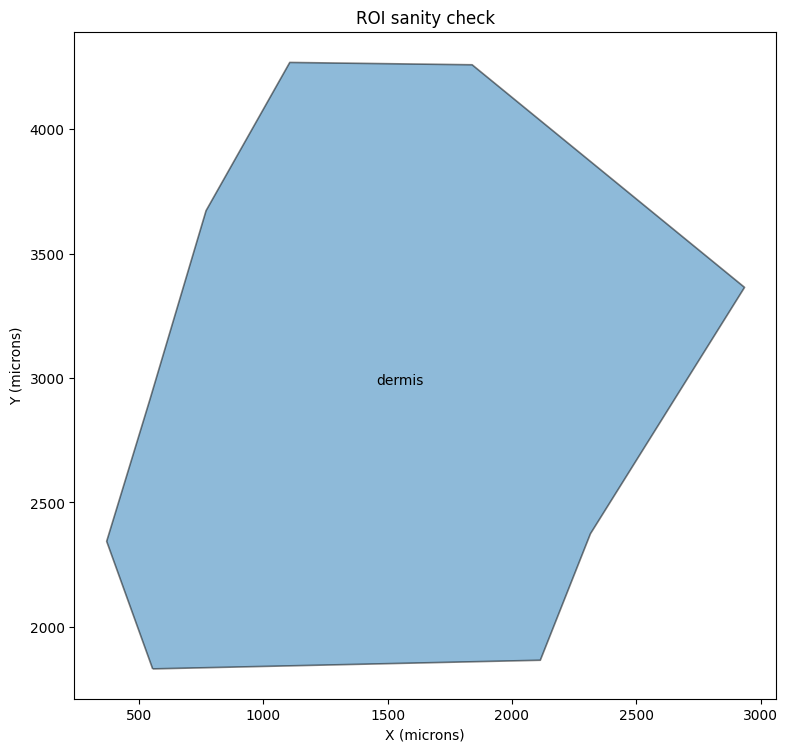


--- Setting geometries ---
trx geometry: geometry_micron
cell geometry: centroid
ROI geometry: geometry
Number of ROIs: 1

--- Spatial join ---

--- Computing per-ROI metrics ---

Processing ROI: dermis
Total number of transcripts in dermis: 6129512
Total number of cells in dermis: 15666
Cell-assigned transcripts in dermis: 4395979
Cell-unassigned transcripts in dermis: 1733533
Unique genes in dermis: 9138
Top 5 genes:
feature_name
EEF1G     92797
POSTN     90478
COL5A1    45166
THY1      38582
XBP1      35736
dtype: int64


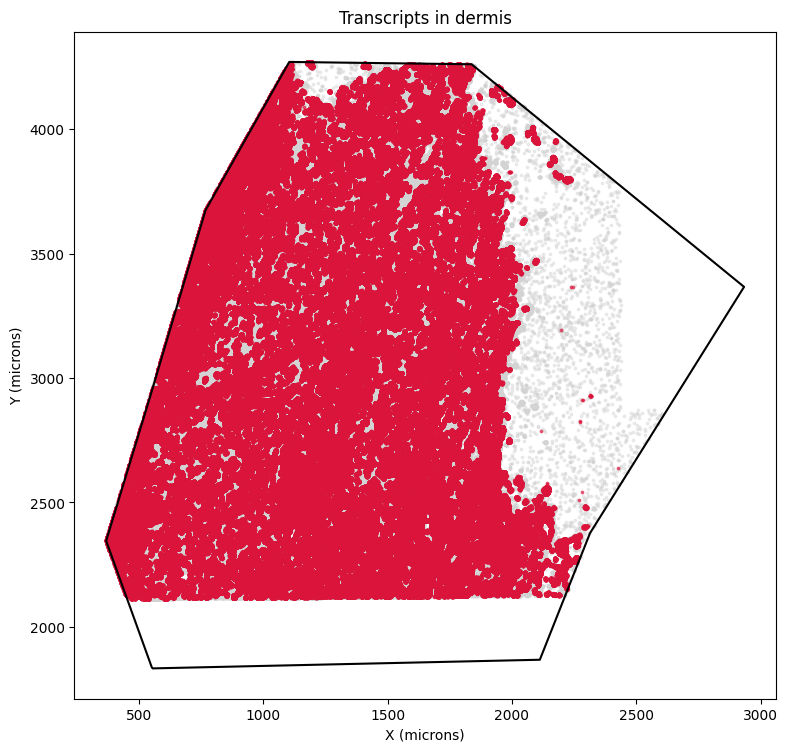

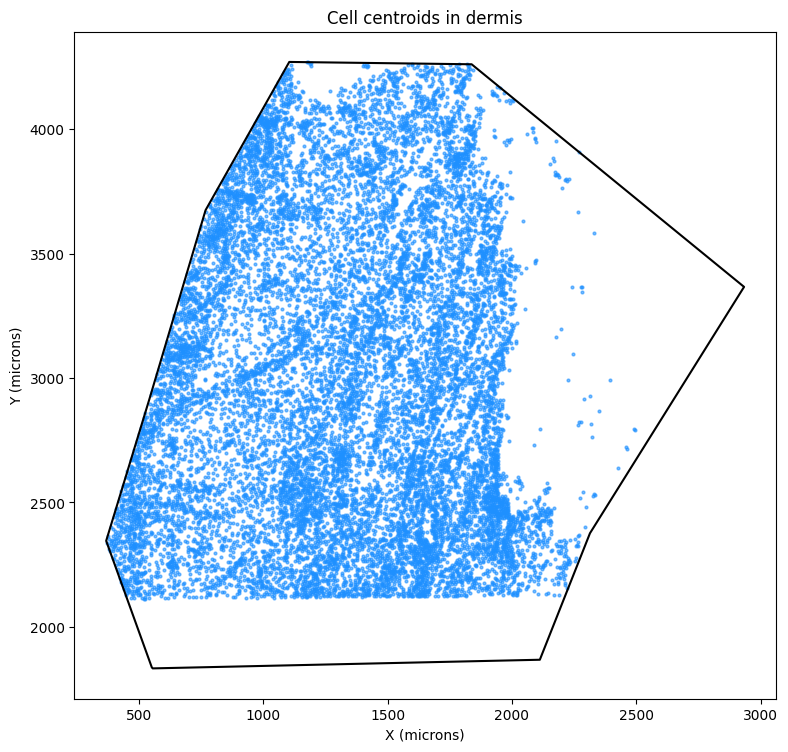

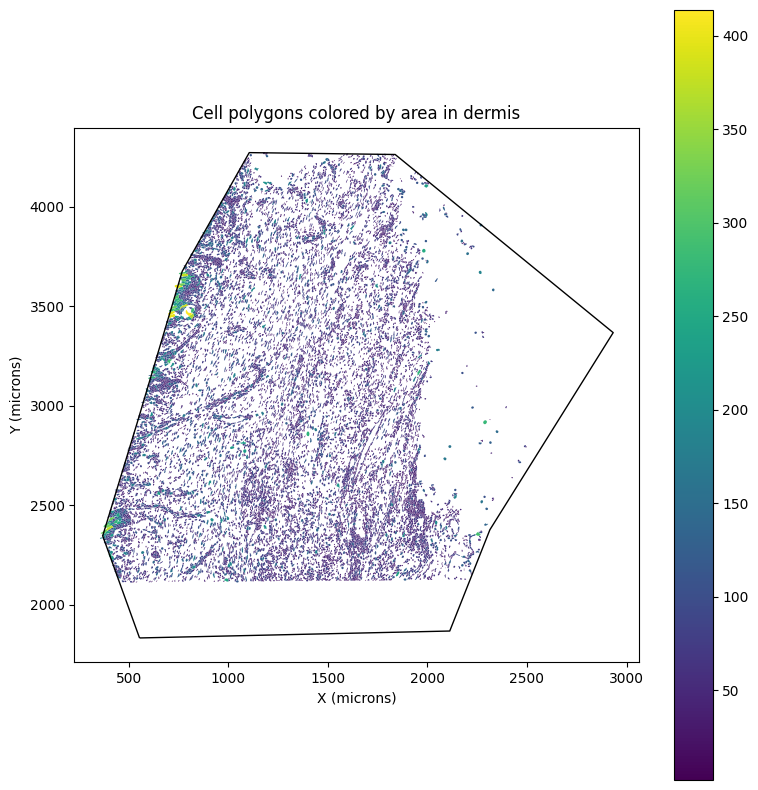

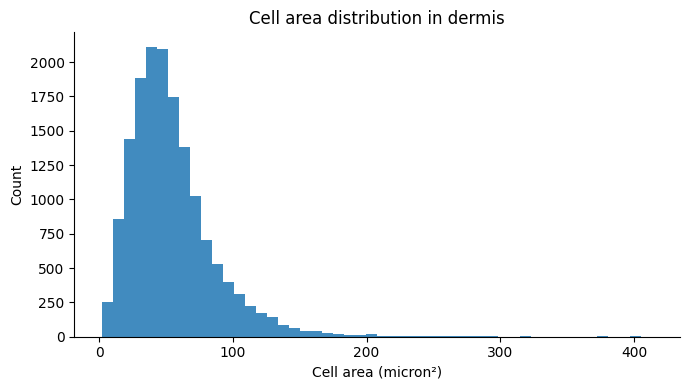

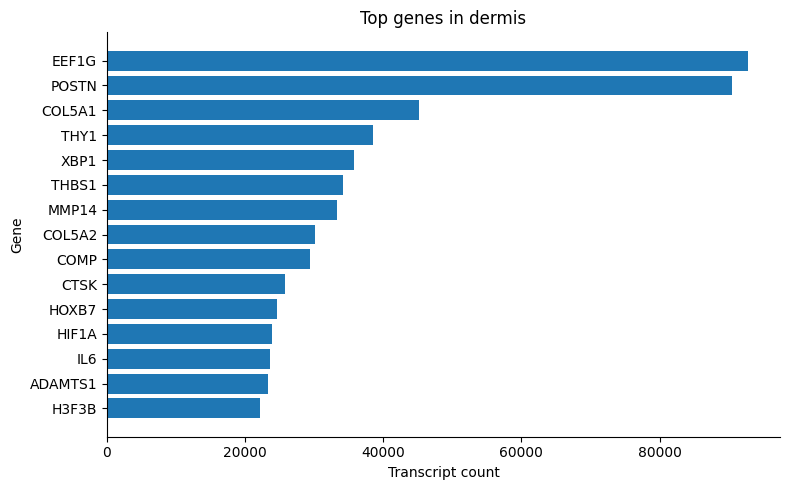

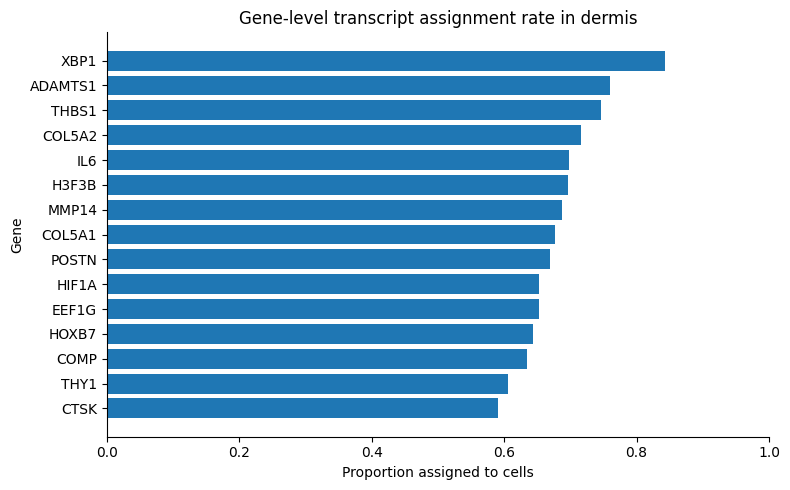


--- QC complete ---
Processed 1 ROIs
Total runtime: 1484.40 seconds



In [6]:
metrics_ROI = xenium_qc_ROI(data_dir, sample, path_landscape_files)

In [8]:
metrics_ROI

{'dermis': {'ROI_area': np.float64(4366108.1916723065),
  'total_trx': 6129512,
  'assigned_trx': 4395979,
  'unassigned_trx': 1733533,
  'prop_unassigned_trx': 0.28281745757247884,
  'total_cells': 15666,
  'average_cell_area': np.float64(54.569381971894074),
  'median_cell_area': np.float64(48.24928192049265),
  'std_cell_area': np.float64(33.15265296402286),
  'average_cell_perimeter': np.float64(30.53580780971822),
  'average_cell_circularity': np.float64(0.7103885145349855),
  'trx_density': np.float64(1.4038845880390964),
  'cell_density': np.float64(0.0035880924870072013),
  'average_trx_per_cell': np.float64(278.98578409595734),
  'median_trx_per_cell': np.float64(216.0),
  'average_genes_per_cell': np.float64(198.62924414545915),
  'median_genes_per_cell': np.float64(170.0),
  'n_unique_genes': 9138,
  'n_unique_genes_cell_assigned_trx': 8874,
  'top_genes': feature_name
  EEF1G      92797
  POSTN      90478
  COL5A1     45166
  THY1       38582
  XBP1       35736
  THBS1     

# Sanity check in Celldega

In [7]:
# landscape = dega.viz.Landscape(
#     technology='Xenium',
#     base_url = f"http://localhost:{dega.viz.get_local_server()}/{path_landscape_files}",
#     nbhd_edit = True,
#     nbhd = ROI_gdf
# )

# landscape

In [ ]:
# hextile of transcript assignment 
# save an anndata of cell assignment to ROIs